In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [6]:
df = pd.read_csv('height-weight.csv')

In [7]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


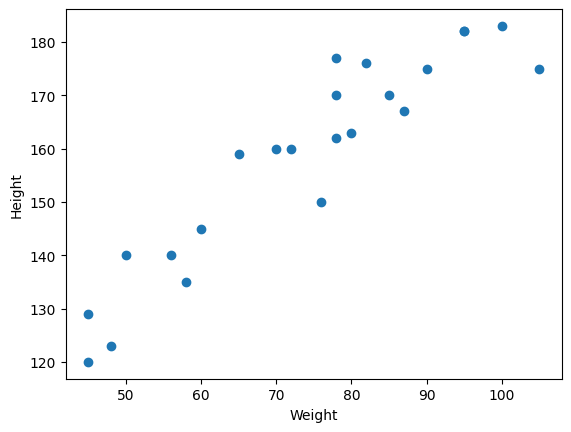

In [8]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [9]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


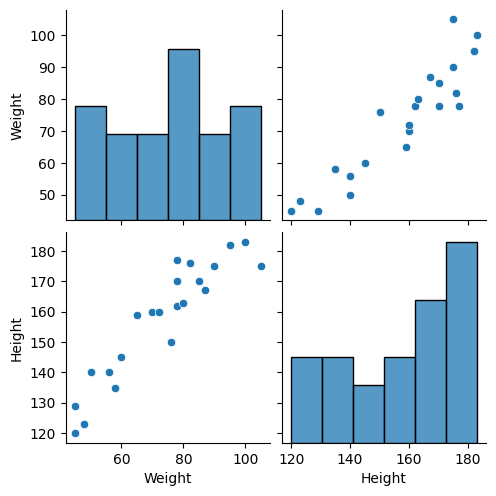

In [10]:
import seaborn as sns
sns.pairplot(df)
plt.show()

In [11]:
#Independant and dependant features
X = df[['Weight']] ## independent feature should be dataframe or 2D array so use [[]]
# np.array(X).shape
Y = df["Height"] ## here this is a variable which can be in a series or in a 1d array i.e can use only []


In [12]:
Y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split


In [14]:
X_train, X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.25,random_state=42)

In [15]:
## standardization
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [17]:
X_test = scaler.transform(X_test)

In [18]:
#Apply simple linear regression
from sklearn.linear_model import LinearRegression

In [19]:
Regression = LinearRegression(n_jobs=-1)

In [20]:
Regression.fit(X_train,Y_train)

LinearRegression(n_jobs=-1)

In [21]:
print("Coefficient or slope :", Regression.coef_)
print("Intercept :", Regression.intercept_)

Coefficient or slope : [17.2982057]
Intercept : 156.47058823529412


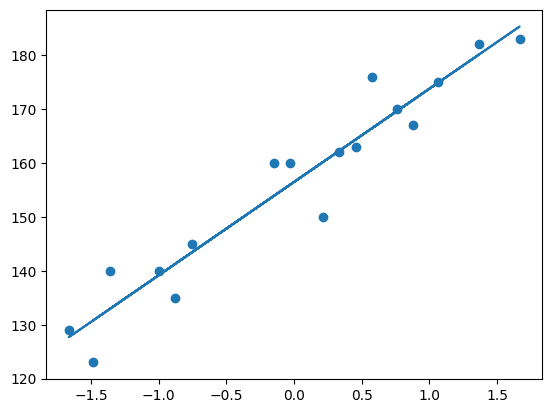

In [22]:
# plot the best fit line
plt.scatter(X_train,Y_train)
plt.plot(X_train,Regression.predict(X_train))
plt.show()

# prediction of test data

1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =80.52 + 1.04(X_test)

In [23]:
#Prediction for test data
y_pred = Regression.predict(X_test)

In [24]:
##Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [25]:
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print("MSE =",mse)
print("MAE =",mae)
print("RMSE =",rmse)

MSE = 114.84069295228699
MAE = 9.665125886795005
RMSE = 10.716374991212605


In [26]:
from sklearn.metrics import r2_score

print(r2_score(Y_test, y_pred))

0.7360826717981276


In [27]:
#OLS linear regression
import statsmodels.api as sm

In [28]:
model = sm.OLS(Y_train,X_train).fit()

In [30]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [31]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 05 Jul 2026   Prob (F-statistic):                       0.664
Time:                        23:31:46   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
Regression.predict(scaler.transform([[72]]))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])